# Estimate π Using Monte Carlo Simulation

This problem estimates the value of π using random sampling.

This is **not** a Bayes' Rule problem.

It belongs to:

```text
Probability
└── Simulation Methods
    └── Monte Carlo Methods
```

The main idea:

> Estimate a geometric quantity by randomly sampling points.


## Step 1: Geometry Setup

Consider a unit square:

$$0 \le x \le 1$$

$$0 \le y \le 1$$

Inside the square, draw a quarter-circle of radius 1.

The area of the square is:

$$1$$

The area of the quarter-circle is:

$$\frac{\pi}{4}$$

So:

$$P(\text{point inside circle}) = \frac{\pi}{4}$$

Therefore:

$$\pi = 4P(\text{point inside circle})$$


## Step 2: Generate Random Points

Generate random points:

$$x \sim Uniform(0, 1)$$

$$y \sim Uniform(0, 1)$$

A point lies inside the quarter-circle if:

$$x^2 + y^2 \le 1$$


In [6]:
import numpy as np

n = 100_000
rng = np.random.default_rng(42)

x = rng.random(n)
y = rng.random(n)

inside = x**2 + y**2 <= 1

pi_estimate = 4 * inside.mean()

pi_estimate

np.float64(3.13776)

The estimate should be close to the true value:

$$\pi \approx 3.14159$$

The estimate improves as the number of random points increases.


In [7]:
import math

actual_pi = math.pi
error = abs(pi_estimate - actual_pi)

pi_estimate, actual_pi, error

(np.float64(3.13776), 3.141592653589793, np.float64(0.0038326535897930114))

## Step 3: Visualize the Random Points

Plot a sample of points inside and outside the quarter-circle.


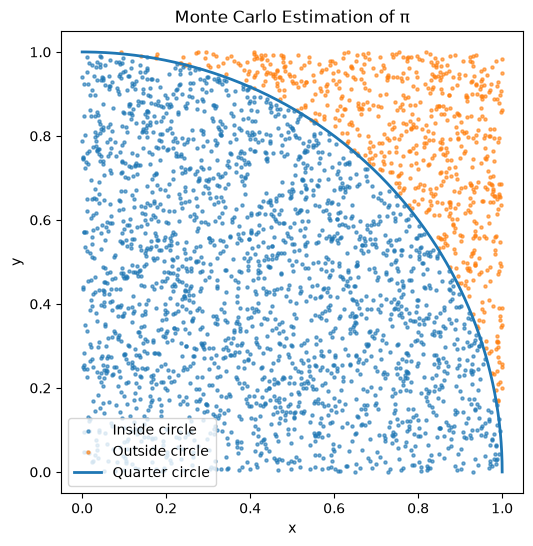

In [8]:
import matplotlib.pyplot as plt

sample_size = 3000

x_sample = x[:sample_size]
y_sample = y[:sample_size]
inside_sample = inside[:sample_size]

plt.figure(figsize=(6, 6))

plt.scatter(
    x_sample[inside_sample],
    y_sample[inside_sample],
    s=5,
    alpha=0.6,
    label="Inside circle",
)

plt.scatter(
    x_sample[~inside_sample],
    y_sample[~inside_sample],
    s=5,
    alpha=0.6,
    label="Outside circle",
)

theta = np.linspace(0, np.pi / 2, 200)
plt.plot(
    np.cos(theta),
    np.sin(theta),
    linewidth=2,
    label="Quarter circle",
)

plt.gca().set_aspect("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Monte Carlo Estimation of π")
plt.legend()
plt.show()

## Step 4: Estimate π for Different Sample Sizes

We can see how the estimate changes as the number of points increases.


In [9]:
sample_sizes = [
    10,
    100,
    1_000,
    10_000,
    100_000,
    1_000_000,
]

estimates = []

for size in sample_sizes:
    x_i = rng.random(size)
    y_i = rng.random(size)

    inside_i = x_i**2 + y_i**2 <= 1

    estimate = 4 * inside_i.mean()
    estimates.append(estimate)

estimates

[np.float64(3.2),
 np.float64(3.36),
 np.float64(3.048),
 np.float64(3.126),
 np.float64(3.145),
 np.float64(3.142084)]

In [10]:
import pandas as pd

results = pd.DataFrame(
    {
        "Sample Size": sample_sizes,
        "Pi Estimate": estimates,
        "Absolute Error": [
            abs(estimate - actual_pi)
            for estimate in estimates
        ],
    }
)

results

,Sample Size,Pi Estimate,Absolute Error
0,10,3.200000,0.058407
1,100,3.360000,0.218407
2,1000,3.048000,0.093593
3,10000,3.126000,0.015593
4,100000,3.145000,0.003407
5,1000000,3.142084,0.000491


## Step 5: Convergence Plot

As the number of samples increases, the estimate tends to get closer to π.


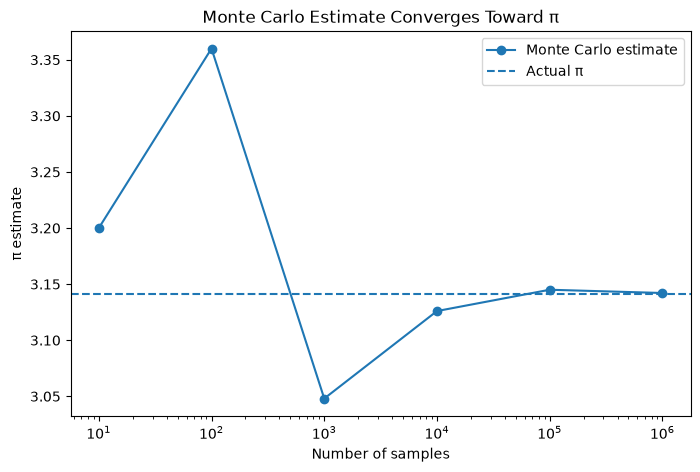

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(
    results["Sample Size"],
    results["Pi Estimate"],
    marker="o",
    label="Monte Carlo estimate",
)

plt.axhline(
    actual_pi,
    linestyle="--",
    label="Actual π",
)

plt.xscale("log")
plt.xlabel("Number of samples")
plt.ylabel("π estimate")
plt.title("Monte Carlo Estimate Converges Toward π")
plt.legend()
plt.show()

## Step 6: Running Estimate

Instead of computing separate estimates, we can track how the estimate changes as more points are sampled.


In [12]:
n = 100_000
rng = np.random.default_rng(123)

x = rng.random(n)
y = rng.random(n)

inside = x**2 + y**2 <= 1

running_inside_count = np.cumsum(inside)
running_total = np.arange(1, n + 1)

running_pi_estimate = 4 * running_inside_count / running_total

running_pi_estimate[-1]

np.float64(3.1436)

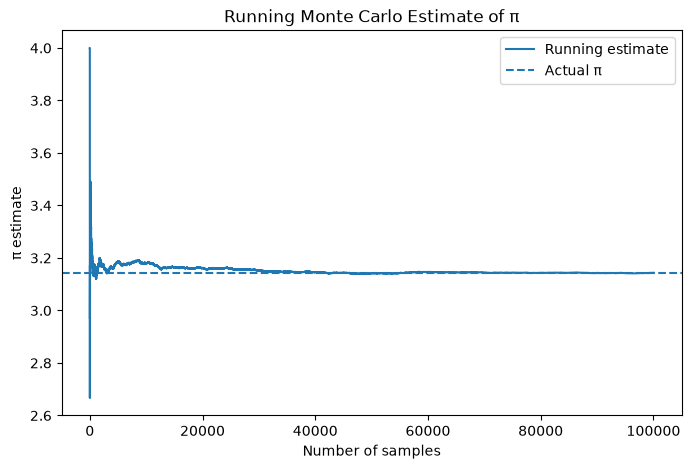

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    running_total,
    running_pi_estimate,
    label="Running estimate",
)

plt.axhline(
    actual_pi,
    linestyle="--",
    label="Actual π",
)

plt.xlabel("Number of samples")
plt.ylabel("π estimate")
plt.title("Running Monte Carlo Estimate of π")
plt.legend()
plt.show()

## Final Answer

Using Monte Carlo simulation:

$$\pi \approx 4 \times \frac{\text{points inside quarter-circle}}{\text{total points}}$$

With enough random samples, this estimate approaches:

$$\pi \approx 3.14159$$


## Key Takeaways

1. This is a Monte Carlo simulation problem.
2. It estimates π using random sampling.
3. The key probability identity is:

$$P(\text{inside circle}) = \frac{\pi}{4}$$

4. More samples generally improve the estimate.
5. The method is simple but converges slowly compared to deterministic numerical methods.
